# SEIRS-SEI Malaria Model

ODE approximation of SEIRS-SEI DDE model with yearly population from IBGE data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [3]:
DATA_DIR = '../../../data_files/data'

climate_data = pd.read_csv(DATA_DIR + '/climate_api_data_2016_2024.csv')
cases_data = pd.read_csv(DATA_DIR + '/sivep_notification_data/treated_malaria_notification_data/cumulative_manaus_cases_2016_2023.csv')
pop_data = pd.read_csv(DATA_DIR + '/ibge_manaus_population_data_2016_2024.csv')
pop_data.rename(columns={'index': 'date'}, inplace=True)

# Load IBGE population data (2000-2025) for yearly N
pop_ibge = pd.read_csv(DATA_DIR + '/ibge_manaus_rural_population_data_2000_2025.csv')
pop_by_year = dict(zip(pop_ibge['year'], pop_ibge['rural_population']))

defor_data = pd.read_csv(DATA_DIR + '/deter_notification_data/treated_deter_deforestation_data_2016_2024.csv')
fires_data = pd.read_csv(DATA_DIR + '/inpe_fire_counts_data_2016_2024.csv')

climate_data['date'] = pd.to_datetime(climate_data['date'])
cases_data['date'] = pd.to_datetime(cases_data['date'])
pop_data['date'] = pd.to_datetime(pop_data['date'])
defor_data['date'] = pd.to_datetime(defor_data['date'])
fires_data['date'] = pd.to_datetime(fires_data['date'])

# Filter data to 2017-01-01 to 2023-12-31
start_date = pd.to_datetime('2017-01-01')
end_date = pd.to_datetime('2023-12-31')
climate_data = climate_data[(climate_data['date'] >= start_date) & (climate_data['date'] <= end_date)].reset_index(drop=True)
cases_data = cases_data[(cases_data['date'] >= start_date) & (cases_data['date'] <= end_date)].reset_index(drop=True)
pop_data = pop_data[(pop_data['date'] >= start_date) & (pop_data['date'] <= end_date)].reset_index(drop=True)

print("Data loaded and filtered successfully!")
print("Climate data:", len(climate_data), "days")
print("Cases data:", len(cases_data), "days")
print("Pop data:", len(pop_data), "days")
print("Deforestation data:", len(defor_data), "days")
print("Forest fires data:", len(fires_data), "days")

print("\nIBGE rural population by year (2017-2023):")
for y in range(2017, 2024):
    print(f"{y}: {pop_by_year[y]:.2f}")

Data loaded and filtered successfully!
Climate data: 2556 days
Cases data: 2556 days
Pop data: 2556 days
Deforestation data: 3288 days
Forest fires data: 3288 days

IBGE rural population by year (2017-2023):
2017: 8368.62
2018: 8260.48
2019: 8152.73
2020: 8045.43
2021: 7938.61
2022: 7832.33
2023: 7942.25


In [4]:
#### Model Parameters 
T_prime = 19.9
B_E = 200
p_ME = 0.9
p_ML = 0.25
p_MP = 0.75
tau_E = 1
tau_P = 1
c1 = 0.00554
c2 = -0.06737
D1 = 36.5
b1 = 0.04
b2 = 0.09
A = -0.03
B = 1.31
C = -4.4
DD = 105
Tmin = 14.5  # critical min temperature for Plasmodium development
gamma = 1/120
R_L = 32.67

# SEIRS parameters
tau_H = 10
omega = 1/365

# Critical temperatures for Plasmodium development
optimal_temp_plasm = 23.5
critical_max_temp_plasm = 29.8
#critical_min_temp_plasm = 14.5 # Tmin

# Critical temperatures for Anopheles development
optimal_temp_anop = 25 #26
critical_max_temp_anop = 34 #40
critical_min_temp_anop = 16 #10

# Rural cases for initial conditions
rural_cases_df = cases_data.copy()
rural_cases_df[['active_total', 'active_symptomatic', 'active_asymptomatic', 'new_cases', 'cumulative_cases', 'active_per_new_case']] = rural_cases_df[['active_total', 'active_symptomatic', 'active_asymptomatic', 'new_cases', 'cumulative_cases', 'active_per_new_case']]*(41.54/100)
I_H0 = round(rural_cases_df['active_total'].iloc[0])
### We will estimate that E_H0 represents about 5% of the human population, while R_H0 is ~15%, given the acquired immunity over time
N_2017 = round(pop_by_year[2017])

E_H0 = round(N_2017 * 0.05)
R_H0 = round(N_2017 * 0.15)

S_H0 = N_2017 - E_H0 - I_H0 - R_H0
### We will later optimize S_H0 to best fit our data

### For starters, we will estimate that the typical ratio of vectors to hosts is in the range of 10-100.
### In the case of Manaus, especially in the rural area, which is a peri-urban area with high humidity, 
### we could put this range at 20-50, so let's say 35:
M_0 = 35 * N_2017
### We will later optimize M (M_0) to best fit our data
### We will also estimate that I_M0 represents ~1% of the initial mosquito population, while E_M0 represents ~3%.
E_M0 = round(M_0 * 0.03)
I_M0 = round(M_0 * 0.01)
S_M0 = M_0 - E_M0 - I_M0
initial_state_2017 = np.array([S_H0, E_H0, I_H0, R_H0, S_M0, E_M0, I_M0])

print(f"Initial human compartments in 2017: N={N_2017}, S_H={S_H0}, E_H={E_H0}, I_H={I_H0}, R_H={R_H0}")
print(f"Initial mosquito compartments in 2017: M={M_0}, S_M={S_M0}, E_M={E_M0}, I_M={I_M0}")

Initial human compartments in 2017: N=8369, S_H=5752, E_H=418, I_H=944, R_H=1255
Initial mosquito compartments in 2017: M=292915, S_M=281199, E_M=8787, I_M=2929


In [5]:
### Helper functions using passed parameters
def tau_L(Temp):
    denom = c1 * Temp + c2
    return 1.0/denom if denom > 0 else 100.0

# def p_T(Temp, Humid):
#     denom = A*Temp**2 + B*Temp + C
#     p_T_temp = np.exp(-1.0 / denom)

#     if Humid < 50:
#         p_T_humid = 0.0
#     elif Humid < 60:
#         p_T_humid = (Humid - 50) / 10.0
#     else:
#         p_T_humid = 1.0
    
#     return p_T_temp * p_T_humid if denom > 0 else 0.0

def p_T(Temp, Humid, H0=58.0, k=0.25, phi=0.05):
    """Adult survival probability of Anopheles darlingi in the Amazon (Epidbot)
    
    Input:
      H0 = 58: Midpoint of the sigmoid (humidity where p_H ≈ 0.5)
      k = 0.25: Transition slope
      phi = 0.05: Minimum survival (micro-habitats)
    
    NOTE: This should use umid_min (daily minimum), NOT umid_med.
    """
    
    denominator = A * Temp**2 + B * Temp + C
    p_T_temp = np.where(denominator <= 0, 0.0, np.exp(-1 / denominator))
    
    p_H = phi + (1.0 - phi) / (1.0 + np.exp(-k * (Humid - H0)))
    
    return p_T_temp * p_H

def mu(Temp, Humid, H0=58.0, k=0.25, phi=0.05):
    p_val = p_T(Temp, Humid, H0, k, phi)
    return -np.log(p_val) if p_val > 0 else 1.0

def a(Temp):
    return max(0, (Temp - T_prime)/D1)

def tau_M(Temp):
    diff = Temp - Tmin
    return DD/diff if diff > 0 else 1000.0

def b_rate(Rain, Temp):
    tau_L_curr = tau_L(Temp)
    if tau_L_curr <= 0: return 0.0
    p_ER = (4*p_ME/R_L**2)*Rain*(R_L - Rain) if 0<=Rain<=R_L else 0.0
    p_LR = (4*p_ML/R_L**2)*Rain*(R_L - Rain) if 0<=Rain<=R_L else 0.0
    p_LT = np.exp(-(c1*Temp + c2))
    p_PR = (4*p_MP/R_L**2)*Rain*(R_L - Rain) if 0<=Rain<=R_L else 0.0
    numer = B_E * p_ER * p_LR * p_LT * p_PR
    denom = tau_E + tau_L_curr + tau_P
    return numer/denom if denom > 0 else 0.0

def b3_briere_unscaled_plasm(Temp):
    return Temp * (Temp - Tmin) * (critical_max_temp_plasm - Temp)**(1/2)
    
unscaled_peak_value_plasm = b3_briere_unscaled_plasm(optimal_temp_plasm)

desired_peak_rate_plasm = 1.0 / tau_M(optimal_temp_plasm) ### b3 at the optimal temperature
eta_plasm = desired_peak_rate_plasm / unscaled_peak_value_plasm

def b3_briere_scaled_plasm(Temp):
    if Temp <= Tmin or Temp >= critical_max_temp_plasm:
        return 0.0
    return eta_plasm * Temp * (Temp - Tmin) * ((critical_max_temp_plasm - Temp)**(1/2))

def temp_factor_briere_normalized_anop(Temp):
    if Temp <= critical_min_temp_anop or Temp >= critical_max_temp_anop:
        return 0.0
    raw = Temp * (Temp - critical_min_temp_anop) * ((critical_max_temp_anop - Temp) ** 0.5)
    opt_raw = optimal_temp_anop * (optimal_temp_anop - critical_min_temp_anop) * ((critical_max_temp_anop - optimal_temp_anop) ** 0.5)
    return min(1.0, raw / opt_raw)

In [6]:
def seirs_sei_ode(t, z, N, year_climate,
                    T_prime, B_E, p_ME, p_ML, p_MP, tau_E, tau_P,
                    c1, c2, D1, b1, b2, A, B, C, DD, 
                    Tmin, optimal_temp_plasm, critical_max_temp_plasm,
                    optimal_temp_anop, critical_max_temp_anop, critical_min_temp_anop,
                    gamma, R_L, M, tau_H, omega, 
                    b3_h=None, b3_m=None):
    
    """SEIRS-SEI ODE with delay approximation (b3 parameters)
    
    Parameters:
    - t: time
    - z: state vector [S_H, E_H, I_H, R_H, S_M, E_M, I_M]
    - N: human population (constant for the year)
    - year_climate: climate DataFrame for the year
    - Model parameters: T_prime, B_E, p_ME, p_ML, p_MP, tau_E, tau_P
    - Climate params: c1, c2, D1, b1, b2, A, B, C, DD, Tmin
    - Epi params: gamma, R_L, M, tau_H, omega
    - b3_h: human delay approx (default 1/tau_H)
    - b3_m: mosquito delay approx (calculated from temp if None)
    """
    # Get climate data
    day_idx = int(t)
    day_idx = np.clip(day_idx, 0, len(year_climate)-1)
    T_curr = year_climate.iloc[day_idx]['temp_med']
    R_curr = year_climate.iloc[day_idx]['precip_med']
    H_curr = year_climate.iloc[day_idx]['umid_min'] ### Substitutes umid_med for umid_min, as that is the humidity that causes stress on the vector
    
    # Current parameters
    mu_curr = mu(T_curr, H_curr)
    a_curr = a(T_curr)
    tau_M_curr = tau_M(T_curr)

    # Delay approximation (1/tau_M & 1/tau_H):
    # Use provided b3_m or calculate from tau_M
    if b3_m is None:
        b3_m_curr = 1.0/tau_M_curr if tau_M_curr > 0 else 0.0
    else:
        b3_m_curr = b3_m
    
    # Use provided b3_h or calculate from tau_H
    if b3_h is None:
        b3_h_curr = 1.0/tau_H if tau_H > 0 else 0.0
    else:
        b3_h_curr = b3_h
    
    l_curr = np.exp(-mu_curr * tau_M_curr)
    b_curr = b_rate(R_curr, T_curr)

    b3_briere_curr = b3_briere_scaled_plasm(T_curr) #### b3, the transition rate from E to I, is the development rate of the Plasmodium
    
    # States
    S_H, E_H, I_H, R_H, S_M, E_M, I_M = z
    
    # Forces of infection
    foi_h = a_curr * b2 * (I_M / N)
    foi_m = a_curr * b1 * (I_H / N)
    
    # Human ODEs (SEIRS)
    dShdt = -foi_h * S_H + omega * R_H
    dEhdt = foi_h * S_H - b3_h_curr * E_H
    dIhdt = b3_h_curr * E_H - gamma * I_H
    dRhdt = gamma * I_H - omega * R_H
    
    # Mosquito ODEs (SEI)

    temp_factor = temp_factor_briere_normalized_anop(T_curr)
    
    habitat_creating_factor = 2*R_curr/R_L
    habitat_flushing_factor = np.exp(1 - (2*R_curr/R_L))
    rain_factor = habitat_creating_factor*habitat_flushing_factor # min(1, max(0, R_curr/30))
    
    K = M_0 * temp_factor * rain_factor #* seasonal_factor
    total_mosq = S_M + E_M + I_M

    ### We decided to include a modification of the Verhurst model: dM/dt = bM(1-M/K):
    ### In this case, if the population of mosquitos ever reaches 0, the growth term becomes 0,
    ### and the population is finished. 
    ### Changing it for dM/dt = bK(1-M/K), we consider that the recruitment comes from a persistent
    ### presence of larvae and eggs in the environment. Even without adult mosquitos, with M approaching 0
    ### the system gives a recovery of the population at a maximum rate of K, making the model more resilient
    ### to environmental shocks.
    density_factor = max(0, 1 - total_mosq/K) if K>0 else 0.0
    mosquito_birth = b_curr * density_factor * K
    ### If M is too small, (1-M/K) is close to 1, so the population grows rapidly

    
    dSmdt = mosquito_birth - foi_m * S_M - mu_curr * S_M
    dEmdt = foi_m * S_M - (mu_curr + (b3_briere_curr * l_curr)) * E_M #foi_m * S_M - (mu_curr + (b3_m_curr * l_curr)) * E_M
    dImdt = b3_briere_curr * l_curr * E_M  - mu_curr * I_M #b3_m_curr * l_curr * E_M  - mu_curr * I_M
    
    # Prevent negative derivatives
    for d in [dShdt, dEhdt, dIhdt, dRhdt, dSmdt, dEmdt, dImdt]:
        d = max(d, -1e6)
    
    return [dShdt, dEhdt, dIhdt, dRhdt, dSmdt, dEmdt, dImdt]


In [7]:
#### Yearly Simulation (2017-2023)
years = list(range(2017, 2024))
all_results = []
current_state = initial_state_2017.copy()

for year in years:
    print(f"\nSimulating {year}...")
    N = round(pop_by_year[year])
    start = f"{year}-01-01"
    end = f"{year}-12-31"
    year_climate = climate_data[(climate_data['date'] >= start) & (climate_data['date'] <= end)].reset_index(drop=True)
    num_days = len(year_climate)
    print(f"Year {year}: N={N}, Days={num_days}")
    
    def ode_func(t, z):
        return seirs_sei_ode(t, z, N, year_climate,
                            T_prime, B_E, p_ME, p_ML, p_MP, tau_E, tau_P,
                            c1, c2, D1, b1, b2, A, B, C, DD, 
                            Tmin, optimal_temp_plasm, critical_max_temp_plasm,
                            optimal_temp_anop, critical_max_temp_anop, critical_min_temp_anop,
                            gamma, R_L, M_0, tau_H, omega)
    
    sol = solve_ivp(ode_func, [0, num_days], current_state, 
                    t_eval=np.linspace(0, num_days, num_days*10), method='LSODA') #'DOP853')
    
    all_results.append({'year': year, 'N': N, 'sol': sol, 'climate': year_climate})
    current_state = sol.y[:, -1].copy()
    print(f"Finished {year}. Final I_H: {round(current_state[2])}, Final I_M: {round(current_state[6])}")

print("\nAll years simulated successfully!")


Simulating 2017...
Year 2017: N=8369, Days=365
Finished 2017. Final I_H: 112, Final I_M: 24

Simulating 2018...
Year 2018: N=8260, Days=365
Finished 2018. Final I_H: 8, Final I_M: 1

Simulating 2019...
Year 2019: N=8153, Days=365
Finished 2019. Final I_H: 1, Final I_M: 0

Simulating 2020...
Year 2020: N=8045, Days=366
Finished 2020. Final I_H: 0, Final I_M: 0

Simulating 2021...
Year 2021: N=7939, Days=365
Finished 2021. Final I_H: 0, Final I_M: 0

Simulating 2022...
Year 2022: N=7832, Days=365
Finished 2022. Final I_H: 0, Final I_M: 0

Simulating 2023...
Year 2023: N=7942, Days=365
Finished 2023. Final I_H: 0, Final I_M: 0

All years simulated successfully!


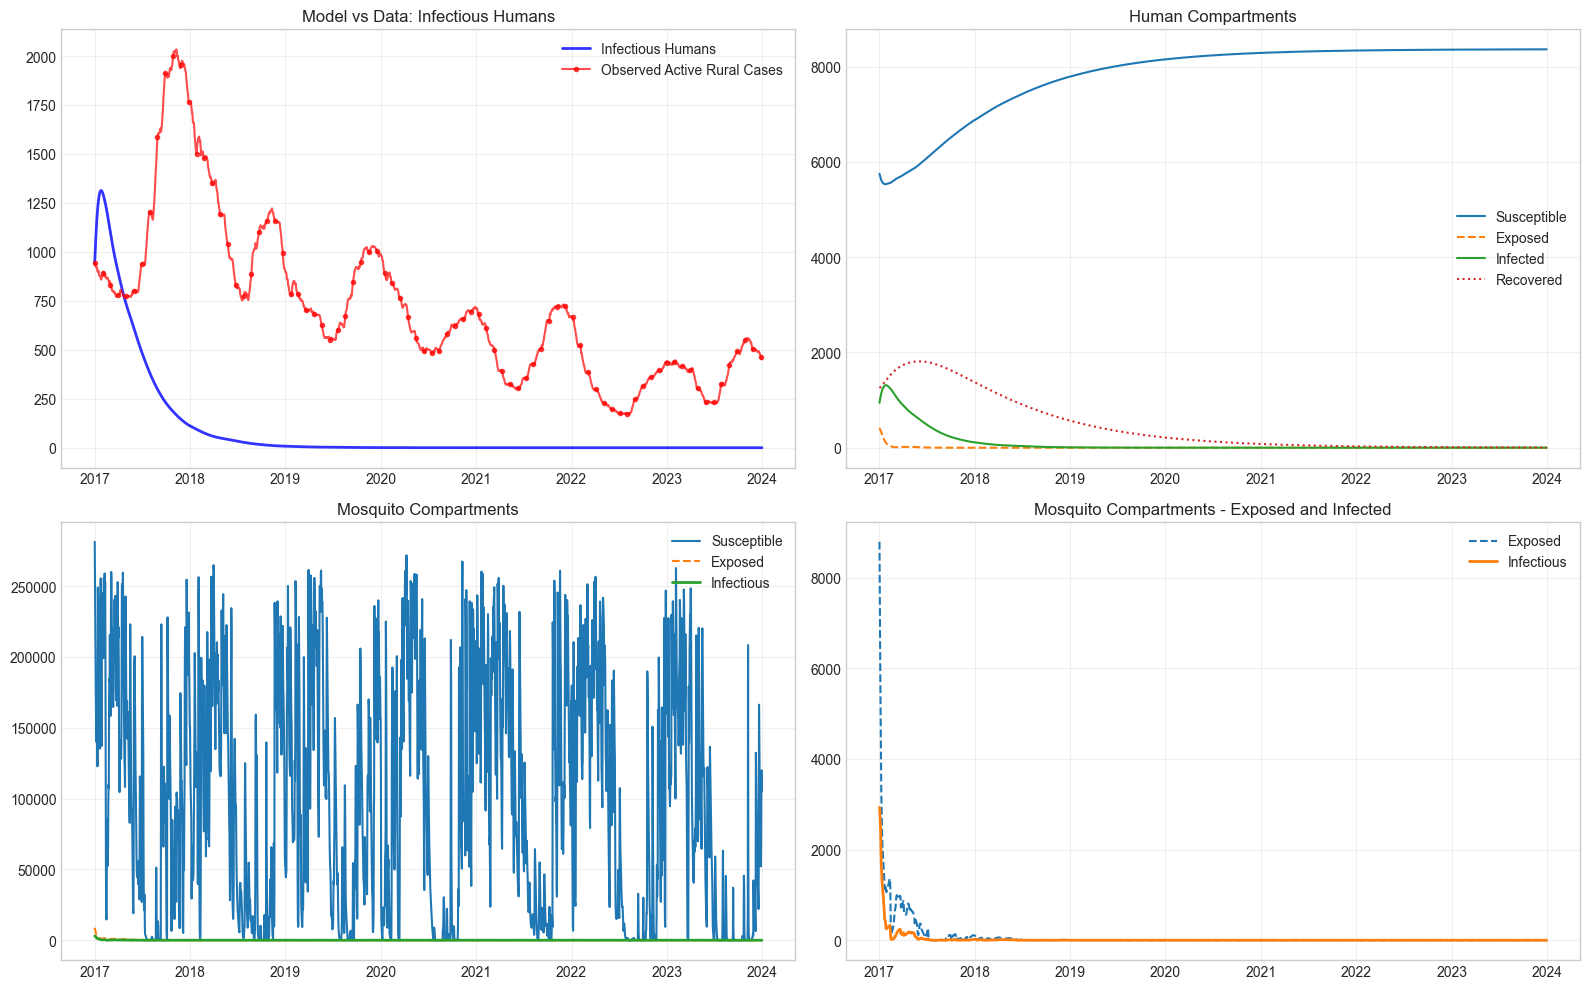

In [8]:
#### Combine and Plot Results
combined_df = pd.DataFrame()
for res in all_results:
    year = res['year']
    sol = res['sol']
    climate = res['climate']
    
    # Interpolate to daily resolution
    t_interp = np.linspace(0, sol.t[-1], len(climate))
    interp = [interp1d(sol.t, sol.y[i])(t_interp) for i in range(7)]
    
    df = pd.DataFrame({
        'date': pd.to_datetime(climate['date']).values,
        'S_H': interp[0], 'E_H': interp[1], 'I_H': interp[2], 'R_H': interp[3],
        'S_M': interp[4], 'E_M': interp[5], 'I_M': interp[6], 'N': res['N']
    })
    combined_df = pd.concat([combined_df, df]).reset_index(drop=True)

# Ensure date columns are datetime
combined_df['date'] = pd.to_datetime(combined_df['date'])
rural_cases_df['date'] = pd.to_datetime(rural_cases_df['date'])

# Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes[0,0].plot(combined_df['date'], combined_df['I_H'], 'b-', linewidth=2, label='Infectious Humans', alpha=0.8)
axes[0,0].plot(rural_cases_df['date'], rural_cases_df['active_total'], 'r-', linewidth=1.5, 
        label='Observed Active Rural Cases', alpha=0.7, marker='o', 
        markersize=3, markevery=30)  # Show markers every ~1 month for readability
axes[0,0].set_title('Model vs Data: Infectious Humans')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(combined_df['date'], combined_df['S_H'], label='Susceptible')
axes[0,1].plot(combined_df['date'], combined_df['E_H'], label='Exposed', linestyle='--')
axes[0,1].plot(combined_df['date'], combined_df['I_H'], label='Infected', linestyle='-')
axes[0,1].plot(combined_df['date'], combined_df['R_H'], label='Recovered', linestyle=':')
axes[0,1].set_title('Human Compartments'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(combined_df['date'], combined_df['S_M'], label='Susceptible', linewidth=1.5)
axes[1,0].plot(combined_df['date'], combined_df['E_M'], label='Exposed', linewidth=1.5, linestyle='--')
axes[1,0].plot(combined_df['date'], combined_df['I_M'], label='Infectious', linewidth=2)
axes[1,0].set_title('Mosquito Compartments'); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

# axes[1,1].plot(combined_df['date'], combined_df['N'], 'k-', linewidth=2, label='Yearly N (IBGE)')
# axes[1,1].set_title('Human Population (Yearly from IBGE)'); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

axes[1,1].plot(combined_df['date'], combined_df['E_M'], label='Exposed', linewidth=1.5, linestyle='--')
axes[1,1].plot(combined_df['date'], combined_df['I_M'], label='Infectious', linewidth=2)
axes[1,1].set_title('Mosquito Compartments - Exposed and Infected'); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


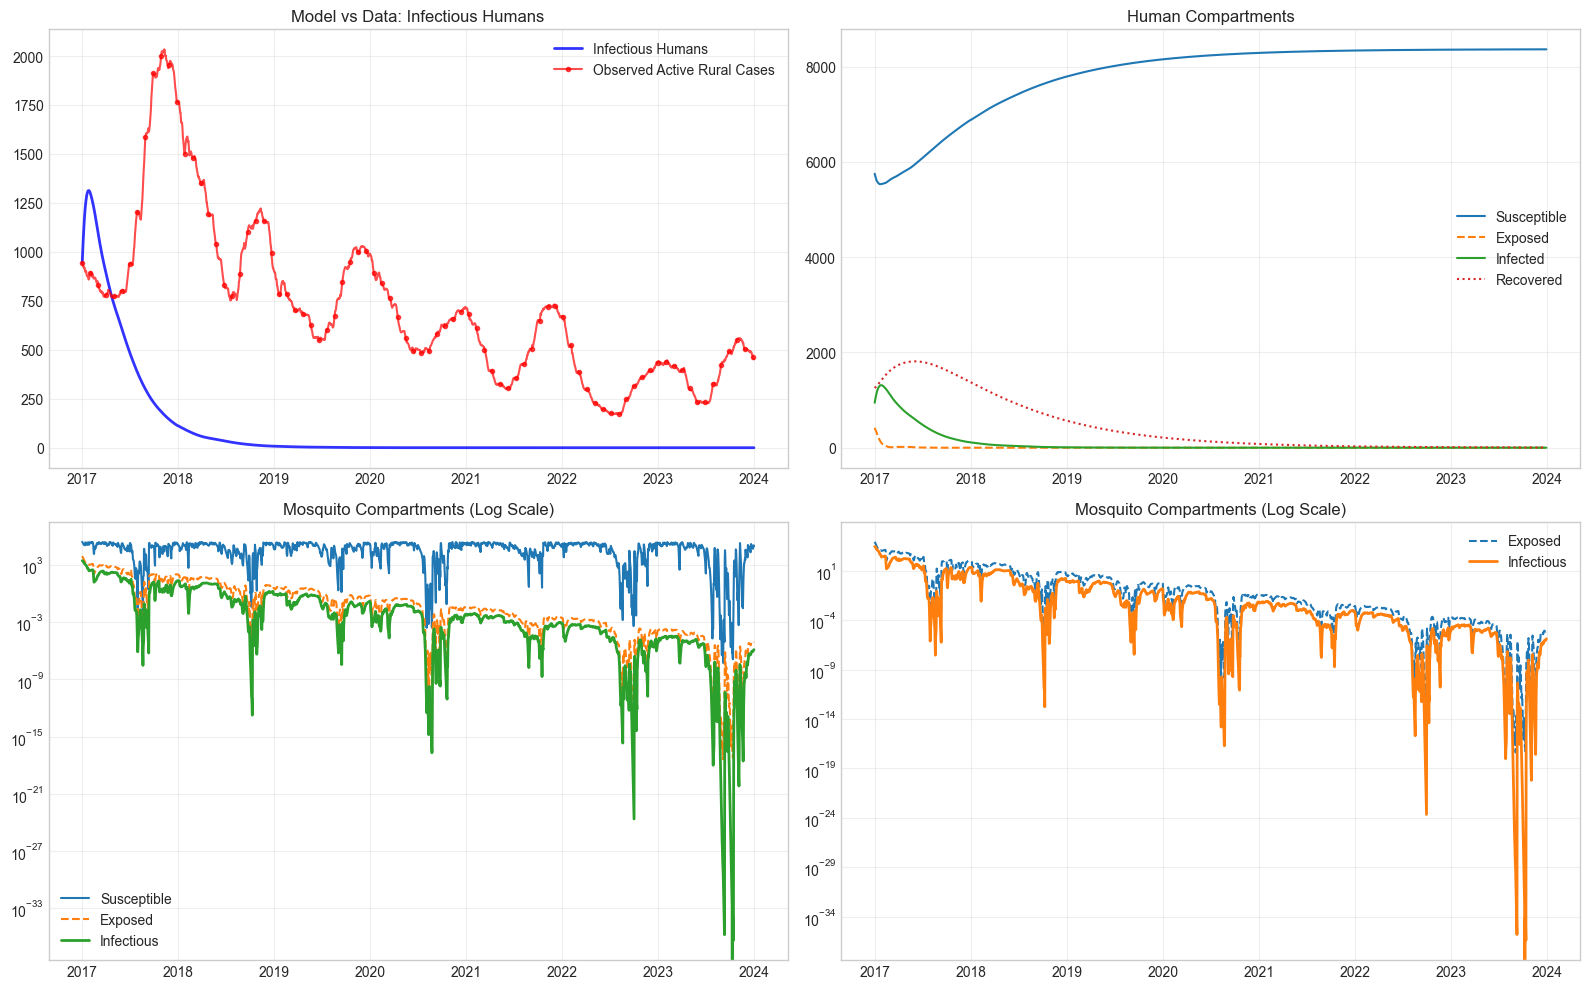

In [9]:
# Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Infectious humans vs observed data
axes[0,0].plot(
    combined_df['date'],
    combined_df['I_H'],
    'b-',
    linewidth=2,
    label='Infectious Humans',
    alpha=0.8
)

axes[0,0].plot(
    rural_cases_df['date'],
    rural_cases_df['active_total'],
    'r-',
    linewidth=1.5,
    label='Observed Active Rural Cases',
    alpha=0.7,
    marker='o',
    markersize=3,
    markevery=30
)

axes[0,0].set_title('Model vs Data: Infectious Humans')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)


# Human compartments
axes[0,1].plot(combined_df['date'], combined_df['S_H'], label='Susceptible')
axes[0,1].plot(combined_df['date'], combined_df['E_H'], label='Exposed', linestyle='--')
axes[0,1].plot(combined_df['date'], combined_df['I_H'], label='Infected', linestyle='-')
axes[0,1].plot(combined_df['date'], combined_df['R_H'], label='Recovered', linestyle=':')

axes[0,1].set_title('Human Compartments')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)


# Mosquito compartments (LOG SCALE)
axes[1,0].plot(
    combined_df['date'],
    combined_df['S_M'],
    label='Susceptible',
    linewidth=1.5
)

axes[1,0].plot(
    combined_df['date'],
    combined_df['E_M'],
    label='Exposed',
    linewidth=1.5,
    linestyle='--'
)

axes[1,0].plot(
    combined_df['date'],
    combined_df['I_M'],
    label='Infectious',
    linewidth=2
)

# Apply logarithmic scale
axes[1,0].set_yscale('log')
axes[1,0].set_title('Mosquito Compartments (Log Scale)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3, which='both')


# # Human population
# axes[1,1].plot(
#     combined_df['date'],
#     combined_df['N'],
#     'k-',
#     linewidth=2,
#     label='Yearly N (IBGE)'
# )

# axes[1,1].set_title('Human Population (Yearly from IBGE)')
# axes[1,1].legend()
# axes[1,1].grid(True, alpha=0.3)

# Mosquito compartments (LOG SCALE)

axes[1,1].plot(
    combined_df['date'],
    combined_df['E_M'],
    label='Exposed',
    linewidth=1.5,
    linestyle='--'
)

axes[1,1].plot(
    combined_df['date'],
    combined_df['I_M'],
    label='Infectious',
    linewidth=2
)

# Apply logarithmic scale
axes[1,1].set_yscale('log')
axes[1,1].set_title('Mosquito Compartments (Log Scale)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

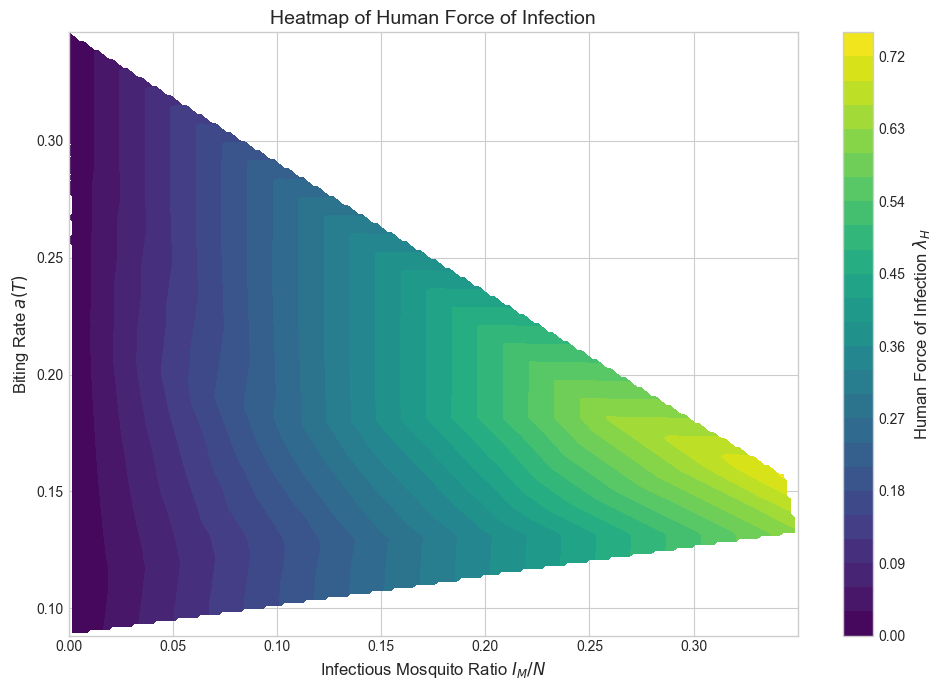

In [10]:
combined_df['Temp'] = climate_data['temp_med'].values[:len(combined_df)]

# Compute a(T) and b3(T)
combined_df['a_T'] = combined_df['Temp'].apply(a)
combined_df['b_3'] = combined_df['Temp'].apply(b3_briere_scaled_plasm)

# Infectious mosquito ratio
combined_df['IM_over_N'] = combined_df['I_M'] / combined_df['N']

# Human force of infection
combined_df['lambda_H'] = ((b2/combined_df['b_3'][0]) * 
    combined_df['a_T']
    * combined_df['IM_over_N']
    * combined_df['S_H'][0]/combined_df['E_H'][0]                       
)

# ============================================================
# Create grid for contourf
# ============================================================

x = combined_df['IM_over_N'].values
y = combined_df['a_T'].values
z = combined_df['lambda_H'].values

# Grid definition
xi = np.linspace(x.min(), x.max(), 200)
yi = np.linspace(y.min(), y.max(), 200)

Xi, Yi = np.meshgrid(xi, yi)

# Interpolate z values onto the grid
from scipy.interpolate import griddata

Zi = griddata(
    (x, y),
    z,
    (Xi, Yi),
    method='linear'
)

# ============================================================
# Plot contourf heatmap
# ============================================================

plt.figure(figsize=(10, 7))

contour = plt.contourf(
    Xi,
    Yi,
    Zi,
    levels=25,
    cmap='viridis'
)

critical_line = plt.contour(
    Xi,
    Yi,
    Zi,
    levels=[1],
    colors='red',
    linewidths=2.5
)

plt.clabel(
    critical_line,
    fmt={1: r'$\lambda_H = 1$'},
    fontsize=11
)

# Colorbar
cbar = plt.colorbar(contour)
cbar.set_label(r'Human Force of Infection $\lambda_H$', fontsize=12)

# Labels
plt.xlabel(r'Infectious Mosquito Ratio $I_M/N$', fontsize=12)
plt.ylabel(r'Biting Rate $a(T)$', fontsize=12)

plt.title(
    r'Heatmap of Human Force of Infection',
    fontsize=14
)

plt.tight_layout()
plt.show()

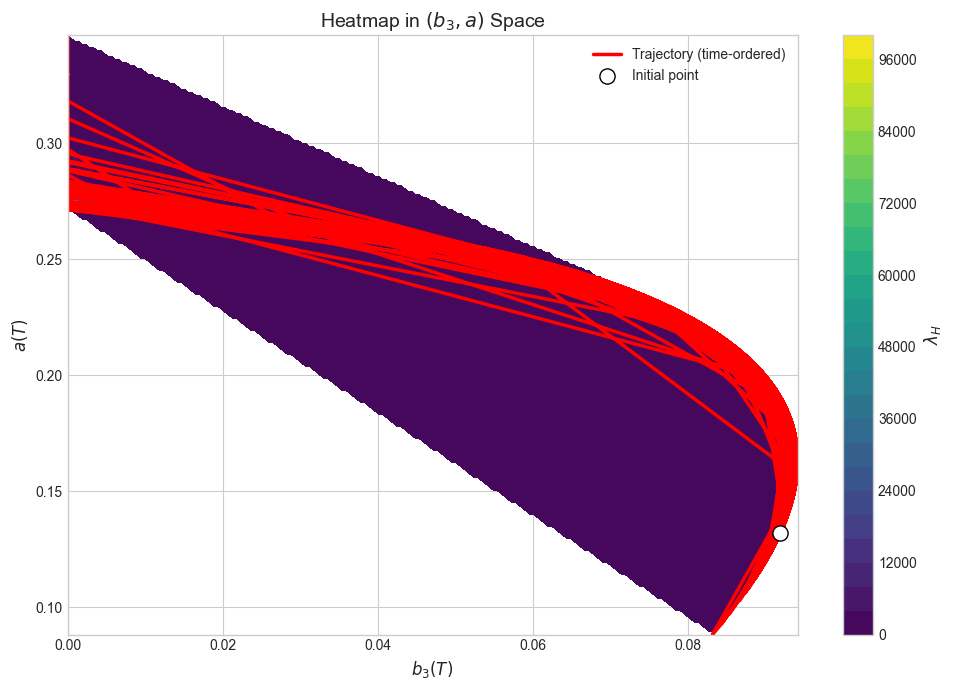

In [11]:
combined_df = combined_df.sort_values('date').reset_index(drop=True)

combined_df['Temp'] = climate_data['temp_med'].values[:len(combined_df)]

combined_df['a_T'] = combined_df['Temp'].apply(a)
combined_df['b_3'] = combined_df['Temp'].apply(b3_briere_scaled_plasm)

eps = 1e-8

combined_df['lambda_H'] = (
    (b2 / (combined_df['b_3'] + eps))
    * combined_df['a_T']
    * combined_df['IM_over_N']
    * (combined_df['S_H'] / (combined_df['E_H'] + eps))
)

x = combined_df['b_3'].values
y = combined_df['a_T'].values
z = combined_df['lambda_H'].values

mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)

x, y, z = x[mask], y[mask], z[mask]

xi = np.linspace(x.min(), x.max(), 200)
yi = np.linspace(y.min(), y.max(), 200)

Xi, Yi = np.meshgrid(xi, yi)

from scipy.interpolate import griddata

Zi = griddata((x, y), z, (Xi, Yi), method='linear')

plt.figure(figsize=(10, 7))

contour = plt.contourf(
    Xi, Yi, Zi,
    levels=25,
    cmap='viridis'
)

cbar = plt.colorbar(contour)
cbar.set_label(r'$\lambda_H$', fontsize=12)

plt.plot(
    combined_df['b_3'].values,
    combined_df['a_T'].values,
    color='red',
    linewidth=2.5,
    label='Trajectory (time-ordered)'
)

plt.scatter(
    combined_df['b_3'].iloc[0],
    combined_df['a_T'].iloc[0],
    color='white',
    edgecolor='black',
    s=120,
    zorder=5,
    label='Initial point'
)

plt.xlabel(r'$b_3(T)$', fontsize=12)
plt.ylabel(r'$a(T)$', fontsize=12)

plt.title(r'Heatmap in $(b_3,a)$ Space', fontsize=14)

plt.legend()
plt.tight_layout()
plt.show()

### ----- Using estimated D1 from data_files/notebooks/Biting_Rate_Estimation.ipynb and T' as minimal temperature for developmet of the vector ----- ###

In [13]:
T_prime = critical_min_temp_anop # 25.6
D1 = 24.8 #4.0 #### Estimated based on data from August 2003 to July 2004 (de Barros, Honório and Arruda (2011))
# b1 = 0.3
# b2 = 0.3

#### Yearly Simulation (2017-2023)
years = list(range(2017, 2024))
all_results = []
current_state = initial_state_2017.copy()

for year in years:
    print(f"\nSimulating {year}...")
    N = round(pop_by_year[year])
    start = f"{year}-01-01"
    end = f"{year}-12-31"
    year_climate = climate_data[(climate_data['date'] >= start) & (climate_data['date'] <= end)].reset_index(drop=True)
    num_days = len(year_climate)
    print(f"Year {year}: N={N}, Days={num_days}")
    
    def ode_func(t, z):
        return seirs_sei_ode(t, z, N, year_climate,
                            T_prime, B_E, p_ME, p_ML, p_MP, tau_E, tau_P,
                            c1, c2, D1, b1, b2, A, B, C, DD, 
                            Tmin, optimal_temp_plasm, critical_max_temp_plasm,
                            optimal_temp_anop, critical_max_temp_anop, critical_min_temp_anop,
                            gamma, R_L, M_0, tau_H, omega)
    
    sol = solve_ivp(ode_func, [0, num_days], current_state, 
                    t_eval=np.linspace(0, num_days, num_days*10), method='LSODA') #'DOP853')
    
    all_results.append({'year': year, 'N': N, 'sol': sol, 'climate': year_climate})
    current_state = sol.y[:, -1].copy()
    print(f"Finished {year}. Final I_H: {round(current_state[2])}, Final I_M: {round(current_state[6])}")
    
print("\nAll years simulated successfully!")


Simulating 2017...
Year 2017: N=8369, Days=365
Finished 2017. Final I_H: 363, Final I_M: 182

Simulating 2018...
Year 2018: N=8260, Days=365
Finished 2018. Final I_H: 93, Final I_M: 23

Simulating 2019...
Year 2019: N=8153, Days=365
Finished 2019. Final I_H: 42, Final I_M: 25

Simulating 2020...
Year 2020: N=8045, Days=366
Finished 2020. Final I_H: 14, Final I_M: 5

Simulating 2021...
Year 2021: N=7939, Days=365
Finished 2021. Final I_H: 10, Final I_M: 4

Simulating 2022...
Year 2022: N=7832, Days=365
Finished 2022. Final I_H: 4, Final I_M: 0

Simulating 2023...
Year 2023: N=7942, Days=365
Finished 2023. Final I_H: 1, Final I_M: 0

All years simulated successfully!


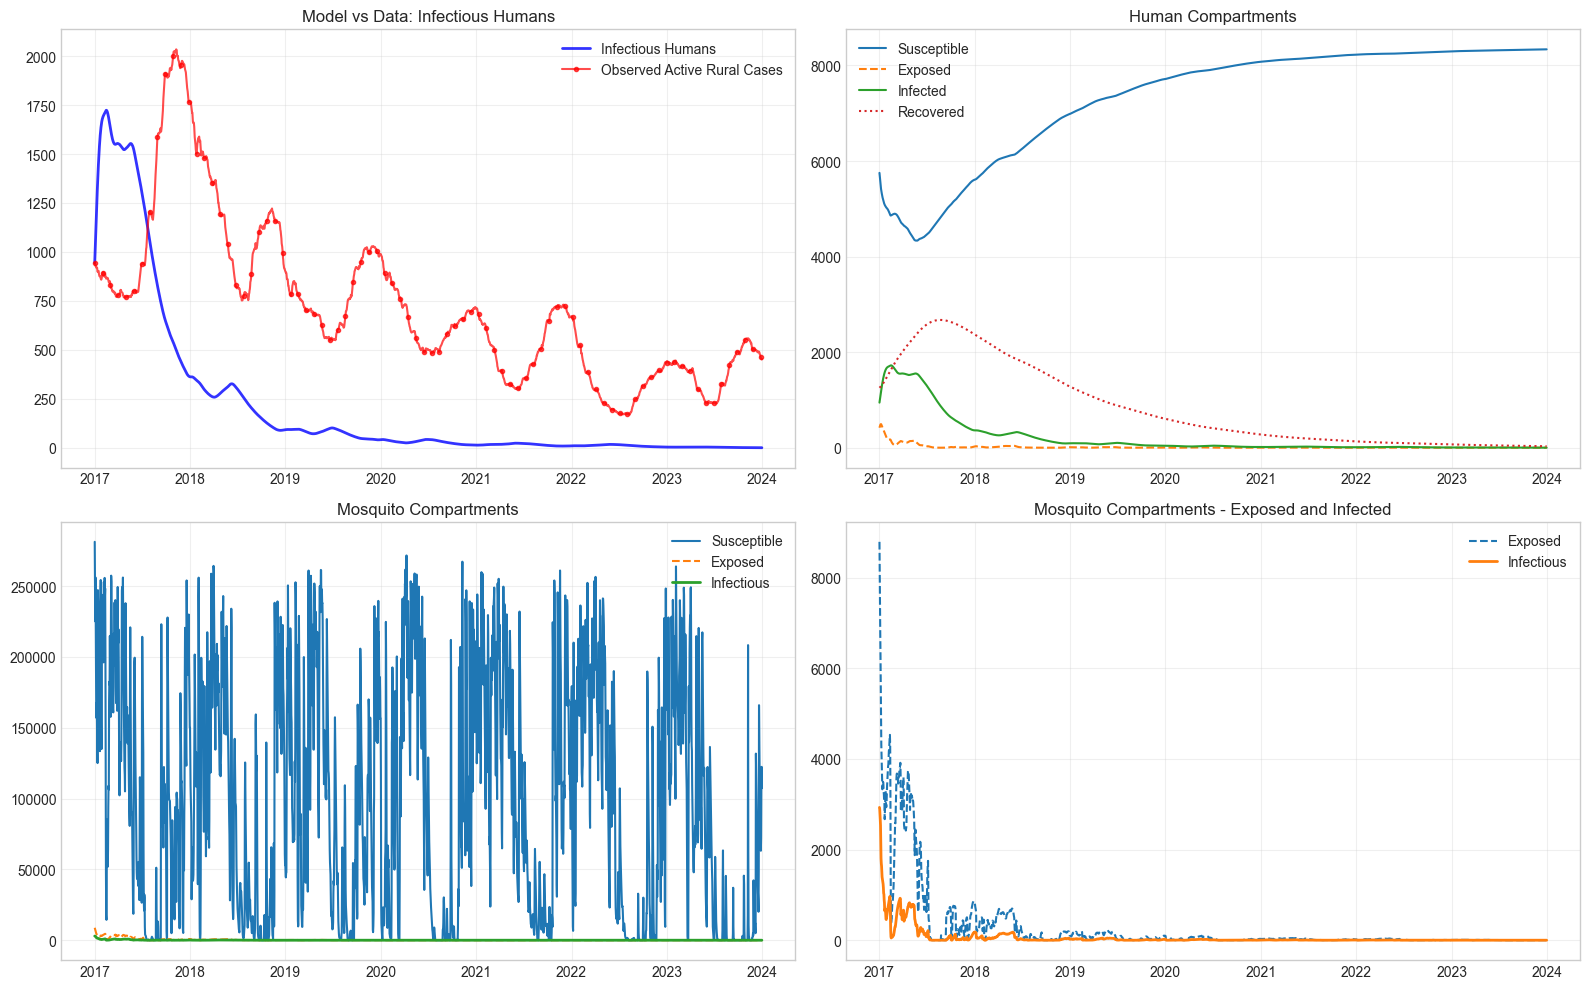

In [14]:
#### Combine and Plot Results
combined_df = pd.DataFrame()
for res in all_results:
    year = res['year']
    sol = res['sol']
    climate = res['climate']
    
    # Interpolate to daily resolution
    t_interp = np.linspace(0, sol.t[-1], len(climate))
    interp = [interp1d(sol.t, sol.y[i])(t_interp) for i in range(7)]
    
    df = pd.DataFrame({
        'date': pd.to_datetime(climate['date']).values,
        'S_H': interp[0], 'E_H': interp[1], 'I_H': interp[2], 'R_H': interp[3],
        'S_M': interp[4], 'E_M': interp[5], 'I_M': interp[6], 'N': res['N']
    })
    combined_df = pd.concat([combined_df, df]).reset_index(drop=True)

# Ensure date columns are datetime
combined_df['date'] = pd.to_datetime(combined_df['date'])
rural_cases_df['date'] = pd.to_datetime(rural_cases_df['date'])

# Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes[0,0].plot(combined_df['date'], combined_df['I_H'], 'b-', linewidth=2, label='Infectious Humans', alpha=0.8)
axes[0,0].plot(rural_cases_df['date'], rural_cases_df['active_total'], 'r-', linewidth=1.5, 
        label='Observed Active Rural Cases', alpha=0.7, marker='o', 
        markersize=3, markevery=30)  # Show markers every ~1 month for readability
axes[0,0].set_title('Model vs Data: Infectious Humans')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(combined_df['date'], combined_df['S_H'], label='Susceptible')
axes[0,1].plot(combined_df['date'], combined_df['E_H'], label='Exposed', linestyle='--')
axes[0,1].plot(combined_df['date'], combined_df['I_H'], label='Infected', linestyle='-')
axes[0,1].plot(combined_df['date'], combined_df['R_H'], label='Recovered', linestyle=':')
axes[0,1].set_title('Human Compartments'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)


axes[1,0].plot(combined_df['date'], combined_df['S_M'], label='Susceptible', linewidth=1.5)
axes[1,0].plot(combined_df['date'], combined_df['E_M'], label='Exposed', linewidth=1.5, linestyle='--')
axes[1,0].plot(combined_df['date'], combined_df['I_M'], label='Infectious', linewidth=2)
axes[1,0].set_title('Mosquito Compartments'); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(combined_df['date'], combined_df['E_M'], label='Exposed', linewidth=1.5, linestyle='--')
axes[1,1].plot(combined_df['date'], combined_df['I_M'], label='Infectious', linewidth=2)
axes[1,1].set_title('Mosquito Compartments - Exposed and Infected'); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

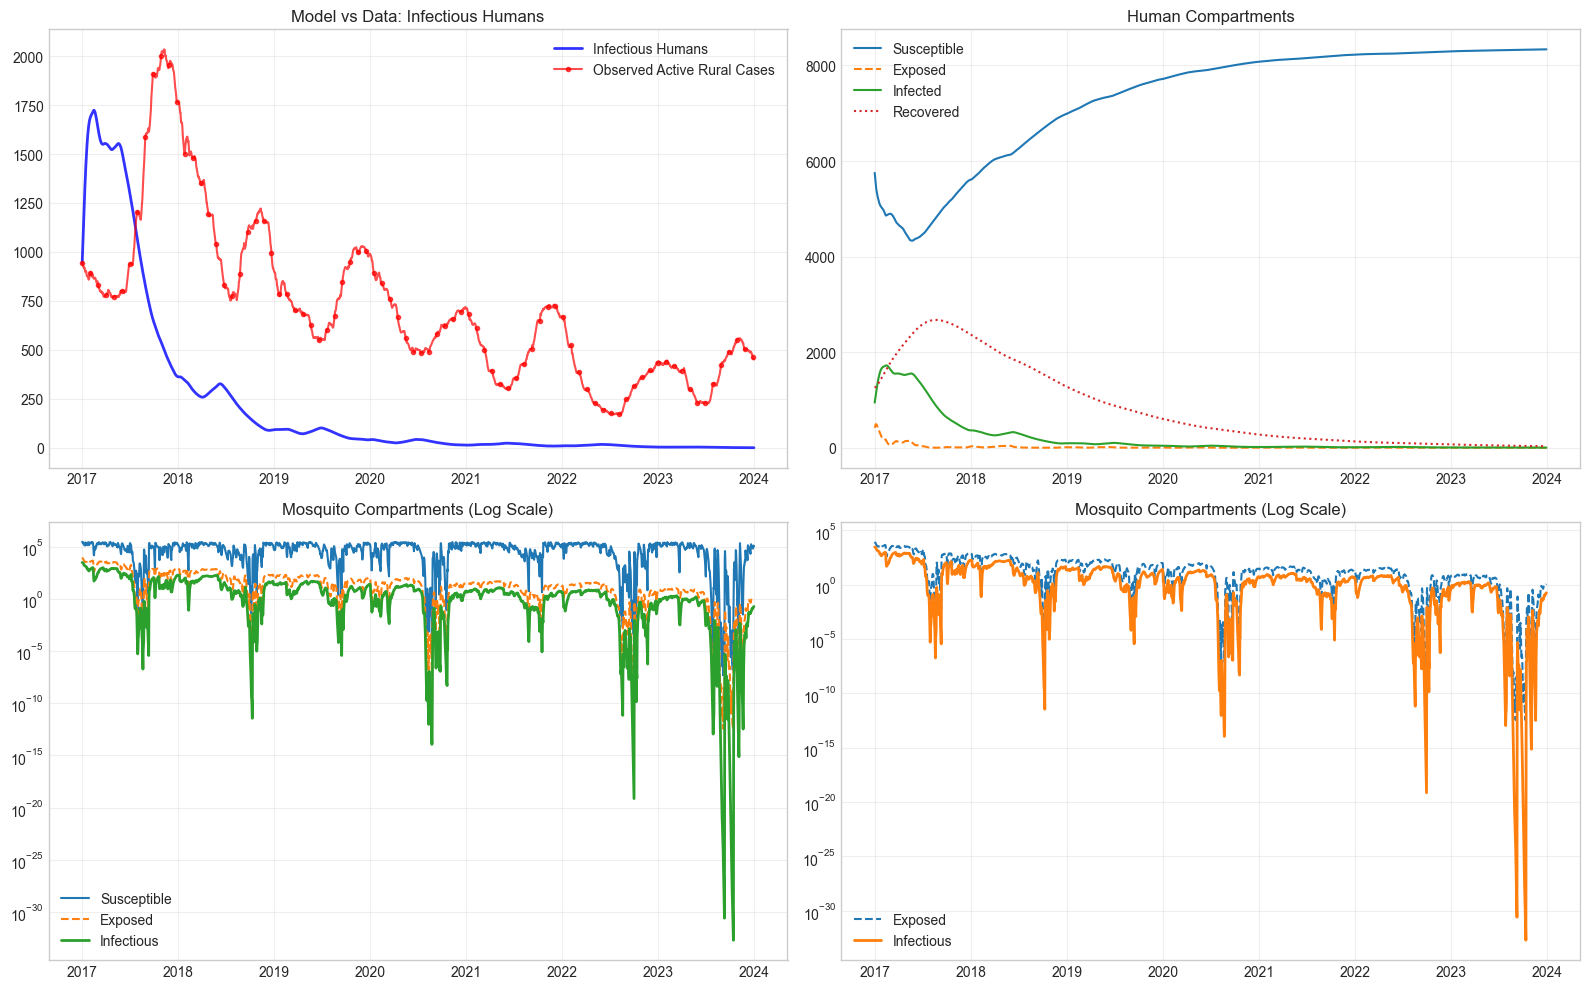

In [15]:
# Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Infectious humans vs observed data
axes[0,0].plot(
    combined_df['date'],
    combined_df['I_H'],
    'b-',
    linewidth=2,
    label='Infectious Humans',
    alpha=0.8
)

axes[0,0].plot(
    rural_cases_df['date'],
    rural_cases_df['active_total'],
    'r-',
    linewidth=1.5,
    label='Observed Active Rural Cases',
    alpha=0.7,
    marker='o',
    markersize=3,
    markevery=30
)

axes[0,0].set_title('Model vs Data: Infectious Humans')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)


# Human compartments
axes[0,1].plot(combined_df['date'], combined_df['S_H'], label='Susceptible')
axes[0,1].plot(combined_df['date'], combined_df['E_H'], label='Exposed', linestyle='--')
axes[0,1].plot(combined_df['date'], combined_df['I_H'], label='Infected', linestyle='-')
axes[0,1].plot(combined_df['date'], combined_df['R_H'], label='Recovered', linestyle=':')

axes[0,1].set_title('Human Compartments')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)


# Mosquito compartments (LOG SCALE)
axes[1,0].plot(
    combined_df['date'],
    combined_df['S_M'],
    label='Susceptible',
    linewidth=1.5
)

axes[1,0].plot(
    combined_df['date'],
    combined_df['E_M'],
    label='Exposed',
    linewidth=1.5,
    linestyle='--'
)

axes[1,0].plot(
    combined_df['date'],
    combined_df['I_M'],
    label='Infectious',
    linewidth=2
)

# Apply logarithmic scale
axes[1,0].set_yscale('log')
axes[1,0].set_title('Mosquito Compartments (Log Scale)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3, which='both')


# # Human population
# axes[1,1].plot(
#     combined_df['date'],
#     combined_df['N'],
#     'k-',
#     linewidth=2,
#     label='Yearly N (IBGE)'
# )

# axes[1,1].set_title('Human Population (Yearly from IBGE)')
# axes[1,1].legend()
# axes[1,1].grid(True, alpha=0.3)

# Mosquito compartments (LOG SCALE)

axes[1,1].plot(
    combined_df['date'],
    combined_df['E_M'],
    label='Exposed',
    linewidth=1.5,
    linestyle='--'
)

axes[1,1].plot(
    combined_df['date'],
    combined_df['I_M'],
    label='Infectious',
    linewidth=2
)

# Apply logarithmic scale
axes[1,1].set_yscale('log')
axes[1,1].set_title('Mosquito Compartments (Log Scale)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

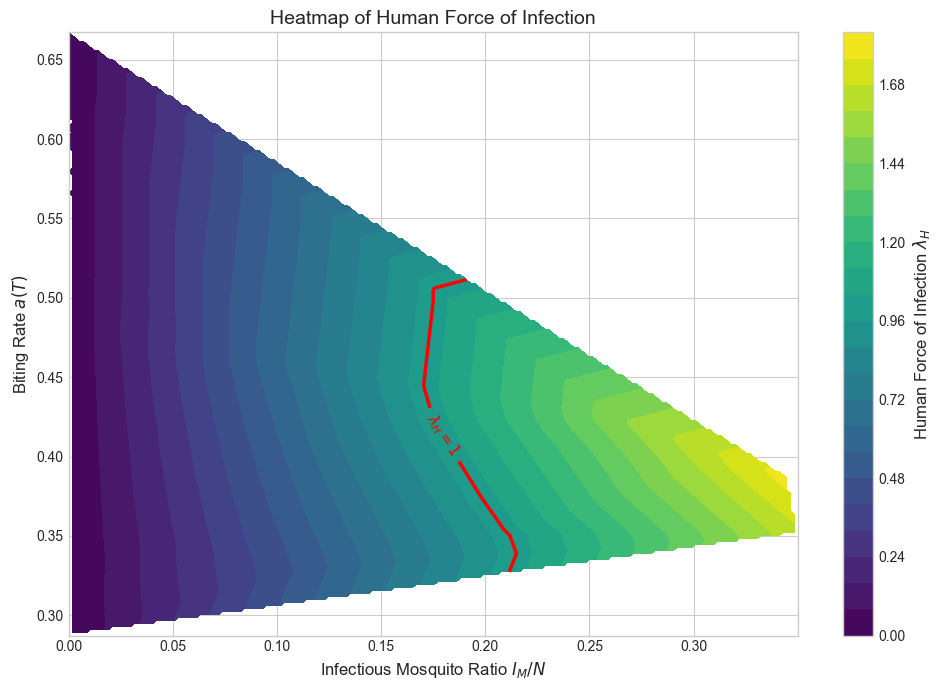

In [16]:
combined_df['Temp'] = climate_data['temp_med'].values[:len(combined_df)]

# Compute a(T) and b3(T)
combined_df['a_T'] = combined_df['Temp'].apply(a)
combined_df['b_3'] = combined_df['Temp'].apply(b3_briere_scaled_plasm)

# Infectious mosquito ratio
combined_df['IM_over_N'] = combined_df['I_M'] / combined_df['N']

# Human force of infection
combined_df['lambda_H'] = ((b2/combined_df['b_3'][0]) * 
    combined_df['a_T']
    * combined_df['IM_over_N']
    * combined_df['S_H'][0]/combined_df['E_H'][0]                       
)

# ============================================================
# Create grid for contourf
# ============================================================

x = combined_df['IM_over_N'].values
y = combined_df['a_T'].values
z = combined_df['lambda_H'].values

# Grid definition
xi = np.linspace(x.min(), x.max(), 200)
yi = np.linspace(y.min(), y.max(), 200)

Xi, Yi = np.meshgrid(xi, yi)

# Interpolate z values onto the grid
from scipy.interpolate import griddata

Zi = griddata(
    (x, y),
    z,
    (Xi, Yi),
    method='linear'
)

# ============================================================
# Plot contourf heatmap
# ============================================================

plt.figure(figsize=(10, 7))

contour = plt.contourf(
    Xi,
    Yi,
    Zi,
    levels=25,
    cmap='viridis'
)

critical_line = plt.contour(
    Xi,
    Yi,
    Zi,
    levels=[1],
    colors='red',
    linewidths=2.5
)

plt.clabel(
    critical_line,
    fmt={1: r'$\lambda_H = 1$'},
    fontsize=11
)

# Colorbar
cbar = plt.colorbar(contour)
cbar.set_label(r'Human Force of Infection $\lambda_H$', fontsize=12)

# Labels
plt.xlabel(r'Infectious Mosquito Ratio $I_M/N$', fontsize=12)
plt.ylabel(r'Biting Rate $a(T)$', fontsize=12)

plt.title(
    r'Heatmap of Human Force of Infection',
    fontsize=14
)

plt.tight_layout()
plt.show()

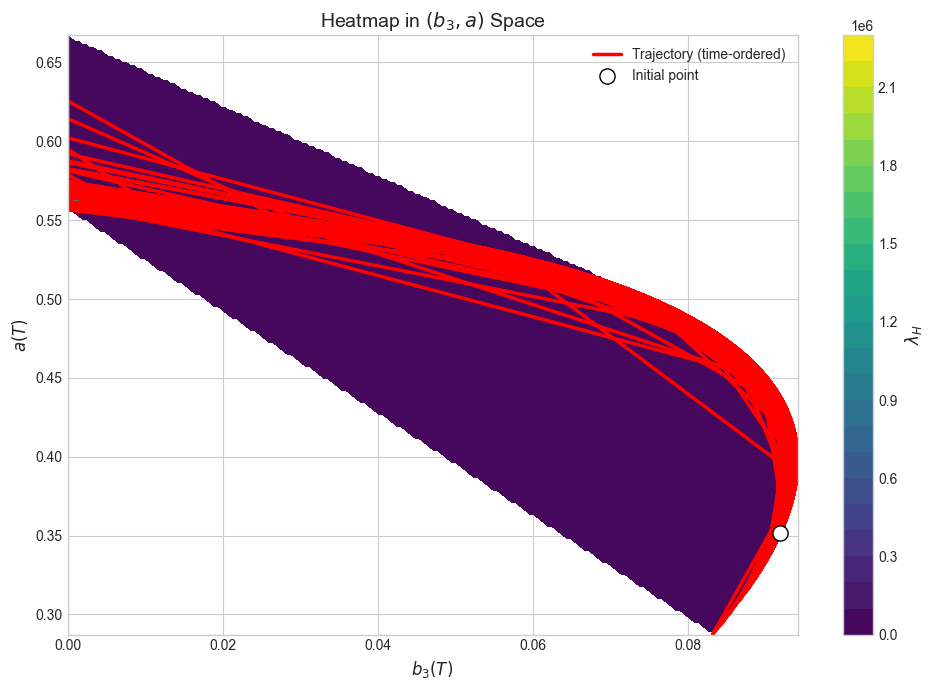

In [17]:
combined_df = combined_df.sort_values('date').reset_index(drop=True)

combined_df['Temp'] = climate_data['temp_med'].values[:len(combined_df)]

combined_df['a_T'] = combined_df['Temp'].apply(a)
combined_df['b_3'] = combined_df['Temp'].apply(b3_briere_scaled_plasm)

eps = 1e-8

combined_df['lambda_H'] = (
    (b2 / (combined_df['b_3'] + eps))
    * combined_df['a_T']
    * combined_df['IM_over_N']
    * (combined_df['S_H'] / (combined_df['E_H'] + eps))
)

x = combined_df['b_3'].values
y = combined_df['a_T'].values
z = combined_df['lambda_H'].values

mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)

x, y, z = x[mask], y[mask], z[mask]

xi = np.linspace(x.min(), x.max(), 200)
yi = np.linspace(y.min(), y.max(), 200)

Xi, Yi = np.meshgrid(xi, yi)

from scipy.interpolate import griddata

Zi = griddata((x, y), z, (Xi, Yi), method='linear')

plt.figure(figsize=(10, 7))

contour = plt.contourf(
    Xi, Yi, Zi,
    levels=25,
    cmap='viridis'
)

cbar = plt.colorbar(contour)
cbar.set_label(r'$\lambda_H$', fontsize=12)

plt.plot(
    combined_df['b_3'].values,
    combined_df['a_T'].values,
    color='red',
    linewidth=2.5,
    label='Trajectory (time-ordered)'
)

plt.scatter(
    combined_df['b_3'].iloc[0],
    combined_df['a_T'].iloc[0],
    color='white',
    edgecolor='black',
    s=120,
    zorder=5,
    label='Initial point'
)

plt.xlabel(r'$b_3(T)$', fontsize=12)
plt.ylabel(r'$a(T)$', fontsize=12)

plt.title(r'Heatmap in $(b_3,a)$ Space', fontsize=14)

plt.legend()
plt.tight_layout()
plt.show()

### ----- Increasing b1 and b2 ----- ###

In [44]:
T_prime = critical_min_temp_anop # 25.6
D1 = 24.8 #4.0 #### Estimated based on data from August 2003 to July 2004 (de Barros, Honório and Arruda (2011))
b1 = 0.06
b2 = 0.12

#### Yearly Simulation (2017-2023)
years = list(range(2017, 2024))
all_results = []
current_state = initial_state_2017.copy()

for year in years:
    print(f"\nSimulating {year}...")
    N = round(pop_by_year[year])
    start = f"{year}-01-01"
    end = f"{year}-12-31"
    year_climate = climate_data[(climate_data['date'] >= start) & (climate_data['date'] <= end)].reset_index(drop=True)
    num_days = len(year_climate)
    print(f"Year {year}: N={N}, Days={num_days}")
    
    def ode_func(t, z):
        return seirs_sei_ode(t, z, N, year_climate,
                            T_prime, B_E, p_ME, p_ML, p_MP, tau_E, tau_P,
                            c1, c2, D1, b1, b2, A, B, C, DD, 
                            Tmin, optimal_temp_plasm, critical_max_temp_plasm,
                            optimal_temp_anop, critical_max_temp_anop, critical_min_temp_anop,
                            gamma, R_L, M_0, tau_H, omega)
    
    sol = solve_ivp(ode_func, [0, num_days], current_state, 
                    t_eval=np.linspace(0, num_days, num_days*10), method='LSODA') #'DOP853')
    
    all_results.append({'year': year, 'N': N, 'sol': sol, 'climate': year_climate})
    current_state = sol.y[:, -1].copy()
    print(f"Finished {year}. Final I_H: {round(current_state[2])}, Final I_M: {round(current_state[6])}")
    
print("\nAll years simulated successfully!")


Simulating 2017...
Year 2017: N=8369, Days=365
Finished 2017. Final I_H: 677, Final I_M: 493

Simulating 2018...
Year 2018: N=8260, Days=365
Finished 2018. Final I_H: 333, Final I_M: 114

Simulating 2019...
Year 2019: N=8153, Days=365
Finished 2019. Final I_H: 421, Final I_M: 350

Simulating 2020...
Year 2020: N=8045, Days=366
Finished 2020. Final I_H: 318, Final I_M: 178

Simulating 2021...
Year 2021: N=7939, Days=365
Finished 2021. Final I_H: 617, Final I_M: 354

Simulating 2022...
Year 2022: N=7832, Days=365
Finished 2022. Final I_H: 355, Final I_M: 44

Simulating 2023...
Year 2023: N=7942, Days=365
Finished 2023. Final I_H: 124, Final I_M: 36

All years simulated successfully!


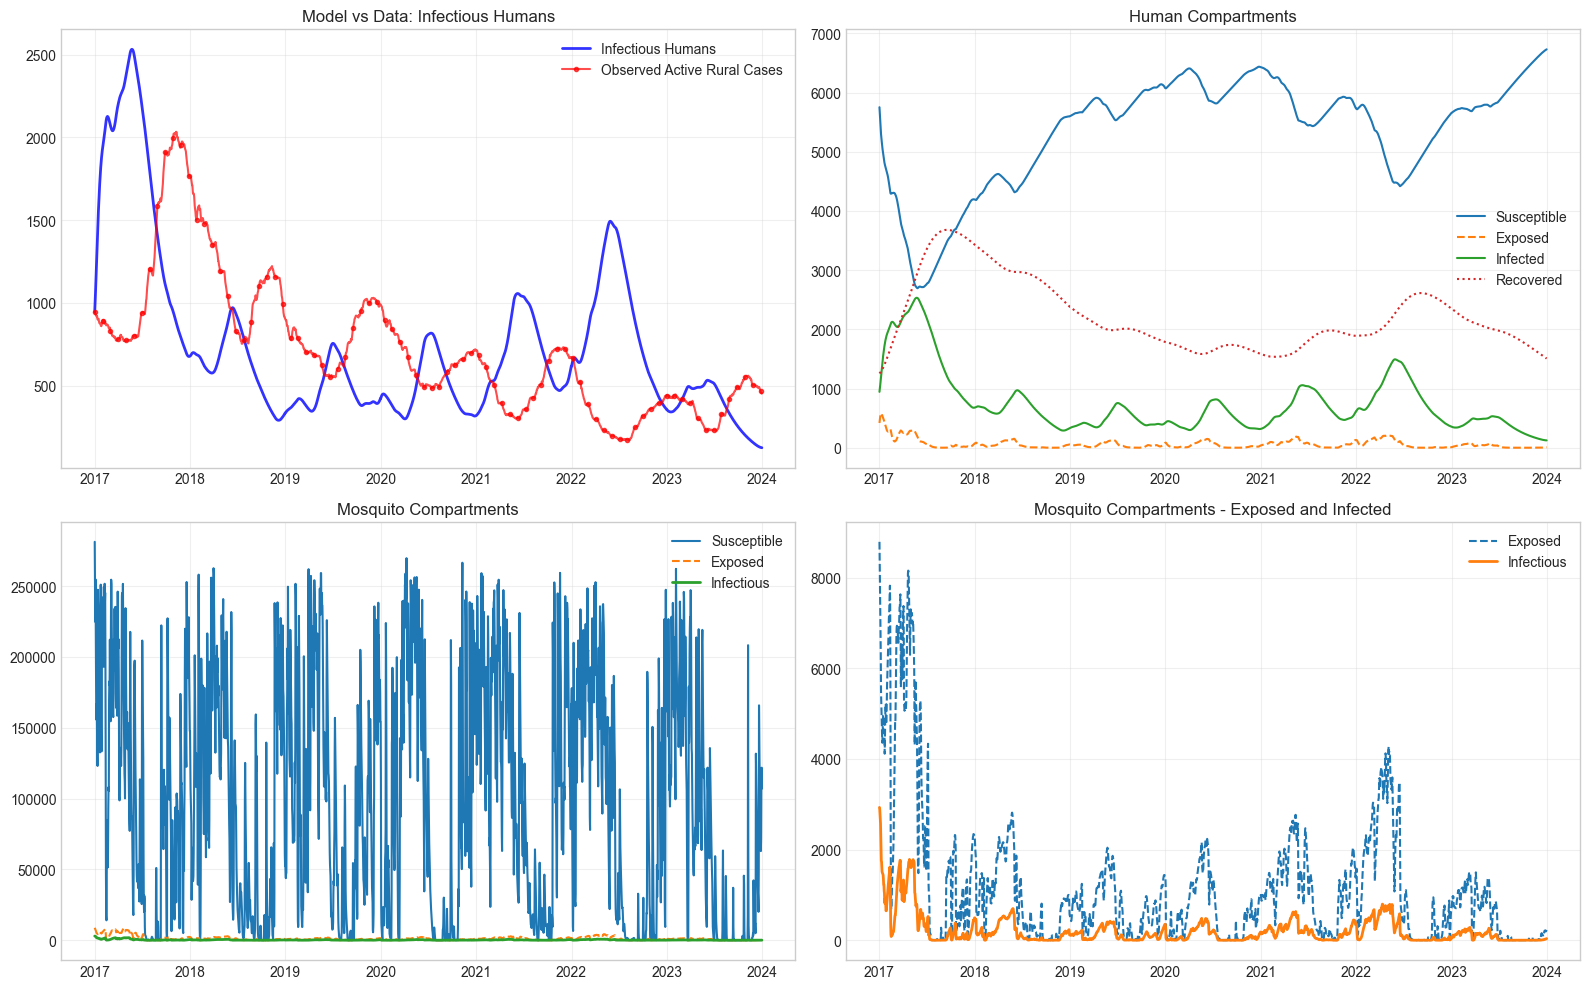

In [45]:
#### Combine and Plot Results
combined_df = pd.DataFrame()
for res in all_results:
    year = res['year']
    sol = res['sol']
    climate = res['climate']
    
    # Interpolate to daily resolution
    t_interp = np.linspace(0, sol.t[-1], len(climate))
    interp = [interp1d(sol.t, sol.y[i])(t_interp) for i in range(7)]
    
    df = pd.DataFrame({
        'date': pd.to_datetime(climate['date']).values,
        'S_H': interp[0], 'E_H': interp[1], 'I_H': interp[2], 'R_H': interp[3],
        'S_M': interp[4], 'E_M': interp[5], 'I_M': interp[6], 'N': res['N']
    })
    combined_df = pd.concat([combined_df, df]).reset_index(drop=True)

# Ensure date columns are datetime
combined_df['date'] = pd.to_datetime(combined_df['date'])
rural_cases_df['date'] = pd.to_datetime(rural_cases_df['date'])

# Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes[0,0].plot(combined_df['date'], combined_df['I_H'], 'b-', linewidth=2, label='Infectious Humans', alpha=0.8)
axes[0,0].plot(rural_cases_df['date'], rural_cases_df['active_total'], 'r-', linewidth=1.5, 
        label='Observed Active Rural Cases', alpha=0.7, marker='o', 
        markersize=3, markevery=30)  # Show markers every ~1 month for readability
axes[0,0].set_title('Model vs Data: Infectious Humans')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(combined_df['date'], combined_df['S_H'], label='Susceptible')
axes[0,1].plot(combined_df['date'], combined_df['E_H'], label='Exposed', linestyle='--')
axes[0,1].plot(combined_df['date'], combined_df['I_H'], label='Infected', linestyle='-')
axes[0,1].plot(combined_df['date'], combined_df['R_H'], label='Recovered', linestyle=':')
axes[0,1].set_title('Human Compartments'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)


axes[1,0].plot(combined_df['date'], combined_df['S_M'], label='Susceptible', linewidth=1.5)
axes[1,0].plot(combined_df['date'], combined_df['E_M'], label='Exposed', linewidth=1.5, linestyle='--')
axes[1,0].plot(combined_df['date'], combined_df['I_M'], label='Infectious', linewidth=2)
axes[1,0].set_title('Mosquito Compartments'); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(combined_df['date'], combined_df['E_M'], label='Exposed', linewidth=1.5, linestyle='--')
axes[1,1].plot(combined_df['date'], combined_df['I_M'], label='Infectious', linewidth=2)
axes[1,1].set_title('Mosquito Compartments - Exposed and Infected'); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

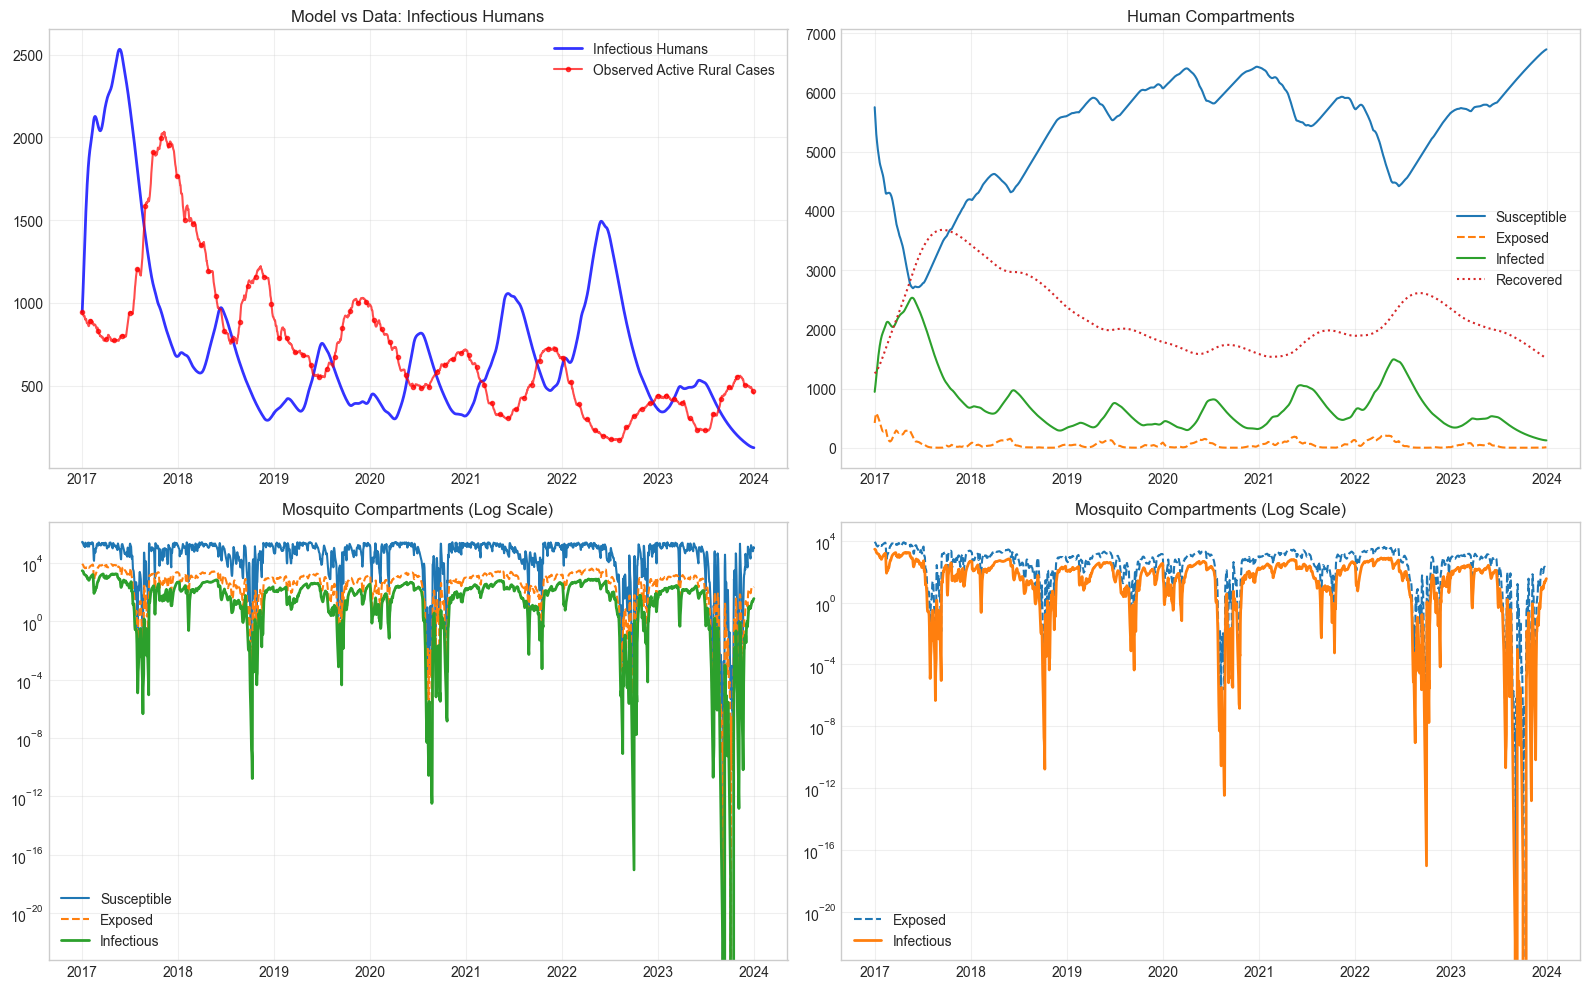

In [46]:
# Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Infectious humans vs observed data
axes[0,0].plot(
    combined_df['date'],
    combined_df['I_H'],
    'b-',
    linewidth=2,
    label='Infectious Humans',
    alpha=0.8
)

axes[0,0].plot(
    rural_cases_df['date'],
    rural_cases_df['active_total'],
    'r-',
    linewidth=1.5,
    label='Observed Active Rural Cases',
    alpha=0.7,
    marker='o',
    markersize=3,
    markevery=30
)

axes[0,0].set_title('Model vs Data: Infectious Humans')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)


# Human compartments
axes[0,1].plot(combined_df['date'], combined_df['S_H'], label='Susceptible')
axes[0,1].plot(combined_df['date'], combined_df['E_H'], label='Exposed', linestyle='--')
axes[0,1].plot(combined_df['date'], combined_df['I_H'], label='Infected', linestyle='-')
axes[0,1].plot(combined_df['date'], combined_df['R_H'], label='Recovered', linestyle=':')

axes[0,1].set_title('Human Compartments')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)


# Mosquito compartments (LOG SCALE)
axes[1,0].plot(
    combined_df['date'],
    combined_df['S_M'],
    label='Susceptible',
    linewidth=1.5
)

axes[1,0].plot(
    combined_df['date'],
    combined_df['E_M'],
    label='Exposed',
    linewidth=1.5,
    linestyle='--'
)

axes[1,0].plot(
    combined_df['date'],
    combined_df['I_M'],
    label='Infectious',
    linewidth=2
)

# Apply logarithmic scale
axes[1,0].set_yscale('log')
axes[1,0].set_title('Mosquito Compartments (Log Scale)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3, which='both')


# # Human population
# axes[1,1].plot(
#     combined_df['date'],
#     combined_df['N'],
#     'k-',
#     linewidth=2,
#     label='Yearly N (IBGE)'
# )

# axes[1,1].set_title('Human Population (Yearly from IBGE)')
# axes[1,1].legend()
# axes[1,1].grid(True, alpha=0.3)

# Mosquito compartments (LOG SCALE)

axes[1,1].plot(
    combined_df['date'],
    combined_df['E_M'],
    label='Exposed',
    linewidth=1.5,
    linestyle='--'
)

axes[1,1].plot(
    combined_df['date'],
    combined_df['I_M'],
    label='Infectious',
    linewidth=2
)

# Apply logarithmic scale
axes[1,1].set_yscale('log')
axes[1,1].set_title('Mosquito Compartments (Log Scale)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

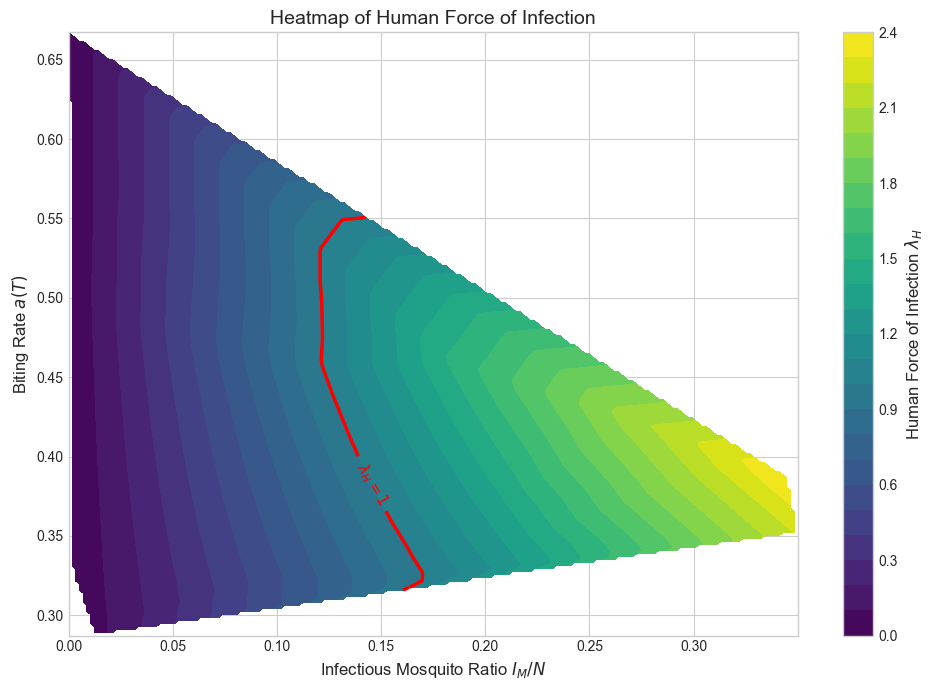

In [47]:
combined_df['Temp'] = climate_data['temp_med'].values[:len(combined_df)]

# Compute a(T) and b3(T)
combined_df['a_T'] = combined_df['Temp'].apply(a)
combined_df['b_3'] = combined_df['Temp'].apply(b3_briere_scaled_plasm)

# Infectious mosquito ratio
combined_df['IM_over_N'] = combined_df['I_M'] / combined_df['N']

# Human force of infection
combined_df['lambda_H'] = ((b2/combined_df['b_3'][0]) * 
    combined_df['a_T']
    * combined_df['IM_over_N']
    * combined_df['S_H'][0]/combined_df['E_H'][0]                       
)

# ============================================================
# Create grid for contourf
# ============================================================

x = combined_df['IM_over_N'].values
y = combined_df['a_T'].values
z = combined_df['lambda_H'].values

# Grid definition
xi = np.linspace(x.min(), x.max(), 200)
yi = np.linspace(y.min(), y.max(), 200)

Xi, Yi = np.meshgrid(xi, yi)

# Interpolate z values onto the grid
from scipy.interpolate import griddata

Zi = griddata(
    (x, y),
    z,
    (Xi, Yi),
    method='linear'
)

# ============================================================
# Plot contourf heatmap
# ============================================================

plt.figure(figsize=(10, 7))

contour = plt.contourf(
    Xi,
    Yi,
    Zi,
    levels=25,
    cmap='viridis'
)

critical_line = plt.contour(
    Xi,
    Yi,
    Zi,
    levels=[1],
    colors='red',
    linewidths=2.5
)

plt.clabel(
    critical_line,
    fmt={1: r'$\lambda_H = 1$'},
    fontsize=11
)

# Colorbar
cbar = plt.colorbar(contour)
cbar.set_label(r'Human Force of Infection $\lambda_H$', fontsize=12)

# Labels
plt.xlabel(r'Infectious Mosquito Ratio $I_M/N$', fontsize=12)
plt.ylabel(r'Biting Rate $a(T)$', fontsize=12)

plt.title(
    r'Heatmap of Human Force of Infection',
    fontsize=14
)

plt.tight_layout()
plt.show()

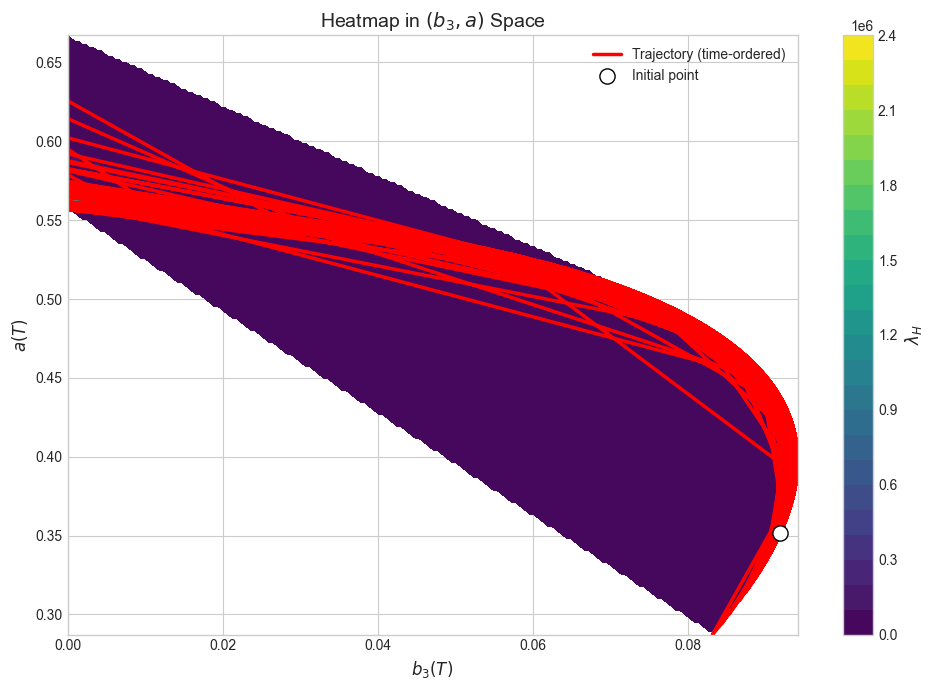

In [48]:
combined_df = combined_df.sort_values('date').reset_index(drop=True)

combined_df['Temp'] = climate_data['temp_med'].values[:len(combined_df)]

combined_df['a_T'] = combined_df['Temp'].apply(a)
combined_df['b_3'] = combined_df['Temp'].apply(b3_briere_scaled_plasm)

eps = 1e-8

combined_df['lambda_H'] = (
    (b2 / (combined_df['b_3'] + eps))
    * combined_df['a_T']
    * combined_df['IM_over_N']
    * (combined_df['S_H'] / (combined_df['E_H'] + eps))
)

x = combined_df['b_3'].values
y = combined_df['a_T'].values
z = combined_df['lambda_H'].values

mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)

x, y, z = x[mask], y[mask], z[mask]

xi = np.linspace(x.min(), x.max(), 200)
yi = np.linspace(y.min(), y.max(), 200)

Xi, Yi = np.meshgrid(xi, yi)

from scipy.interpolate import griddata

Zi = griddata((x, y), z, (Xi, Yi), method='linear')

plt.figure(figsize=(10, 7))

contour = plt.contourf(
    Xi, Yi, Zi,
    levels=25,
    cmap='viridis'
)

cbar = plt.colorbar(contour)
cbar.set_label(r'$\lambda_H$', fontsize=12)

plt.plot(
    combined_df['b_3'].values,
    combined_df['a_T'].values,
    color='red',
    linewidth=2.5,
    label='Trajectory (time-ordered)'
)

plt.scatter(
    combined_df['b_3'].iloc[0],
    combined_df['a_T'].iloc[0],
    color='white',
    edgecolor='black',
    s=120,
    zorder=5,
    label='Initial point'
)

plt.xlabel(r'$b_3(T)$', fontsize=12)
plt.ylabel(r'$a(T)$', fontsize=12)

plt.title(r'Heatmap in $(b_3,a)$ Space', fontsize=14)

plt.legend()
plt.tight_layout()
plt.show()